In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [127]:
df= pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


#### "median house value" is the label, rest columns are the features

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [129]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [130]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

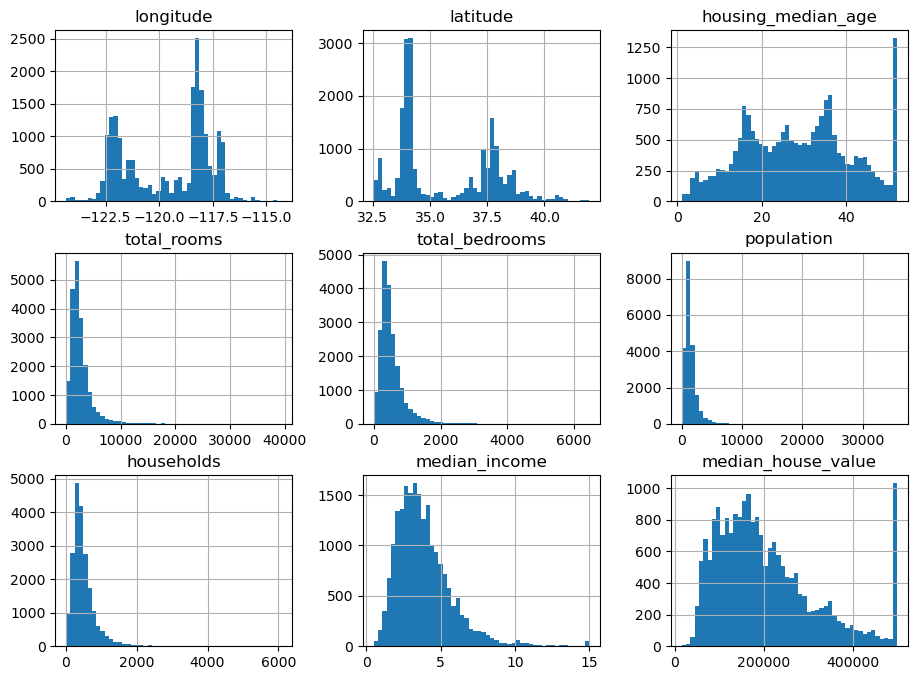

In [131]:
df.hist(bins=50, figsize=(11,8)) # plotting a histogram for every numeric column

## Creating a Test Set

In [132]:
df['income_cat'] = pd.cut(df['median_income'], bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf], labels=[1, 2, 3, 4, 5])
# creates a new column, having values 1 to 5 according to the value of median_income that falls in corresponding bin
# values in range of 6.0 to infinity, falls in 5th bin

Text(0, 0.5, 'Number of Instances')

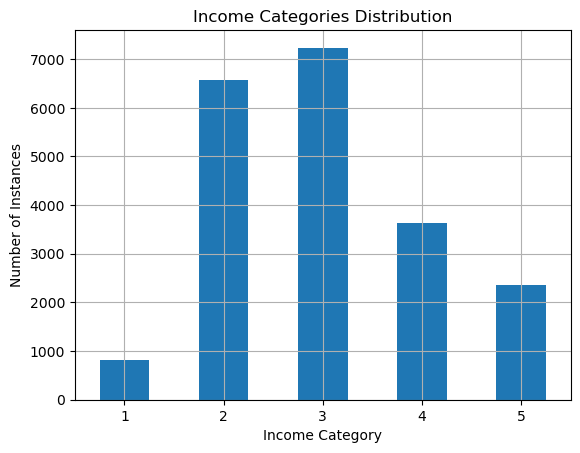

In [133]:
df["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)

#rot=0, sets the rotation of labels of x-axis to 0
plt.title("Income Categories Distribution")
plt.xlabel("Income Category")
plt.ylabel("Number of Instances") 

In [134]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df['income_cat']): 
    strat_train_set = df.iloc[train_index]
    strat_test_set = df.iloc[test_index]

# Explained below

In [135]:
from sklearn.model_selection import StratifiedShuffleSplit
# using this bcz we want the training and testing sets to be representative of the whole dataset/population — especially with respect to a specific column (label or feature).
# ye na ho k kuch labels training me jayn hi na or sary k sary testing waly me chlay jayn

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# n_splits=1 is saying: “I only need one stratified train_test split". n_splits=5 will create 5 different train_test splits
# random_state=42 Ensures that it always give the same split

for train_index, test_index in split.split(df, df['income_cat']): # Split the rows of 'df' such that the distribution of values in 'income_cat' is preserved in both the train and test sets. Other columns are not guaranteed to have the same distribution in train and test
    strat_train_set = df.iloc[train_index]
    strat_test_set = df.iloc[test_index]

# .split(X, y) expects y to be Categorical (i.e., a small number of distinct groups), Not continuous
# If that column has continuous values, you must need to bin it before using here
# If you pass a non-binned continuous column (like median_income, house_value, etc.): it will try to treat each unique value as a category (resulting in thousands of classes)

# this loop runs only once when n_splits=1
# but still we need for loop here bcz .split() always returns an iterator, even when n_splits=1, so we need a for loop (or next()) to extract the single split.

# train_index: array of all positions of rows that go into the training set
# test_index: array of all positions of rows that go into the test set

print(train_index)
print(test_index)
strat_train_set.head()

[12655 15502  2908 ... 19263 19140 19773]
[ 5241 17352  3505 ... 17223 10786  3965]


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND,2
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN,5
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND,2
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN,2
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN,3


Text(0, 0.5, 'Number of Instances')

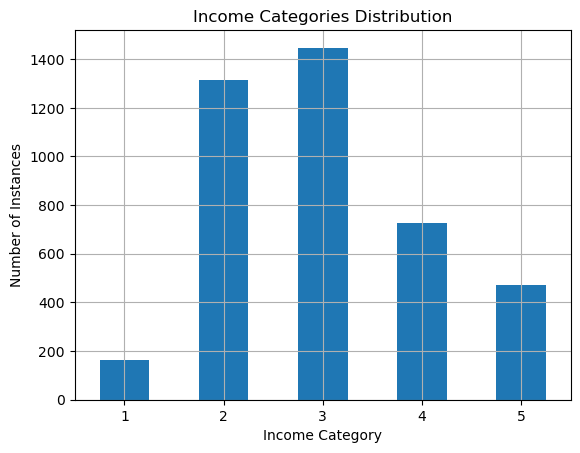

In [136]:
strat_test_set["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.title("Income Categories Distribution")
plt.xlabel("Income Category")
plt.ylabel("Number of Instances") 

#The following graph shows that data has same distribution in strat_test_set as in original data

Text(0, 0.5, 'Number of Instances')

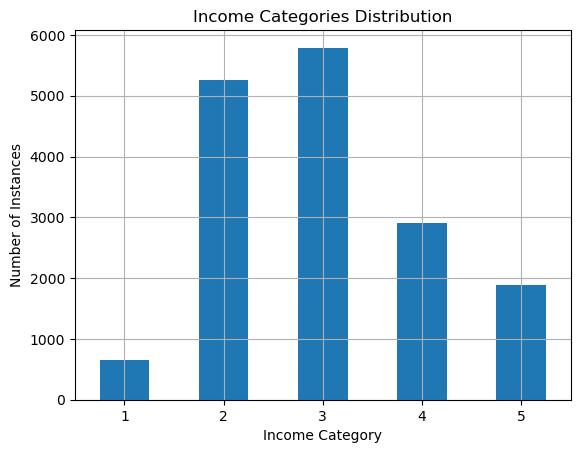

In [137]:
strat_train_set["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.title("Income Categories Distribution")
plt.xlabel("Income Category")
plt.ylabel("Number of Instances")

#The following graph shows that data has same distribution in strat_train_set as in original data

In [138]:
# Remove the 'income_cat' column
for sett in (strat_train_set, strat_test_set): # this loop will run only 2 time. 1st time, sett will contain train_set and 2nd time, sett will contain test_set
    sett.drop('income_cat', axis=1, inplace=True) # it will drop column from train_set and test_set. bcz variables like this (sett) points to object in memory

C:\Users\Qasim Saddique\AppData\Local\Temp\ipykernel_7148\1142889149.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sett.drop('income_cat', axis=1, inplace=True) # it will drop column from train_set and test_set. bcz variables like this (sett) points to object in memory
C:\Users\Qasim Saddique\AppData\Local\Temp\ipykernel_7148\1142889149.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sett.drop('income_cat', axis=1, inplace=True) # it will drop column from train_set and test_set. bcz variables like this (sett) points to object in memory


In [139]:
strat_train_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN


In [140]:
df= strat_train_set.copy() # we will not touch testing data

## Visualizing The Data

<Axes: xlabel='latitude', ylabel='longitude'>

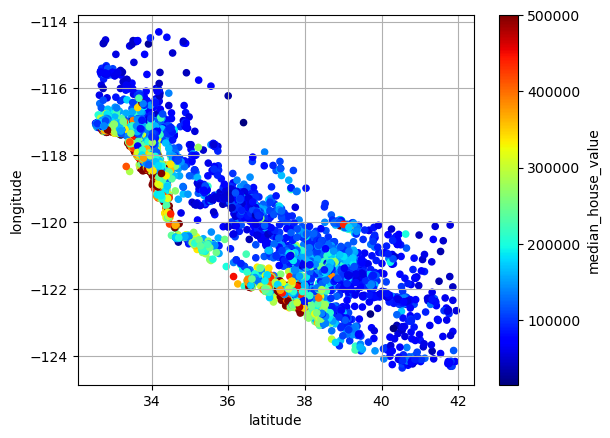

In [141]:
df.plot(kind="scatter", x="latitude", y="longitude", grid=True, c="median_house_value", cmap="jet")

# Equivilent to:

# plt.scatter(
#     df["latitude"],
#     df["longitude"],
#     c=df["median_house_value"],  
#     cmap="jet",
# )
# plt.colorbar(label="Median House Value")
# plt.xlabel("Latitude")
# plt.ylabel("Longitude")
# plt.grid(True)

# Red marked houses have high prices

In [142]:
# To see the correlations bw whole df, drop the string type column

df.drop(labels="ocean_proximity", inplace=True, axis=1)
corr_matrix=df.corr()
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924478,-0.105823,0.048909,0.076686,0.108071,0.063146,-0.019615,-0.047466
latitude,-0.924478,1.000000,0.005737,-0.039245,-0.072550,-0.115290,-0.077765,-0.075146,-0.142673
housing_median_age,-0.105823,0.005737,1.000000,-0.364535,-0.325101,-0.298737,-0.306473,-0.111315,0.114146
total_rooms,0.048909,-0.039245,-0.364535,1.000000,0.929391,0.855103,0.918396,0.200133,0.135140
total_bedrooms,0.076686,-0.072550,-0.325101,0.929391,1.000000,0.876324,0.980167,-0.009643,0.047781
population,0.108071,-0.115290,-0.298737,0.855103,0.876324,1.000000,0.904639,0.002421,-0.026882
households,0.063146,-0.077765,-0.306473,0.918396,0.980167,0.904639,1.000000,0.010869,0.064590
median_income,-0.019615,-0.075146,-0.111315,0.200133,-0.009643,0.002421,0.010869,1.000000,0.687151
median_house_value,-0.047466,-0.142673,0.114146,0.135140,0.047781,-0.026882,0.064590,0.687151,1.000000


In [143]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

array([[<Axes: xlabel='housing_median_age', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='median_house_value', ylabel='housing_median_age'>],
       [<Axes: xlabel='housing_median_age', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='median_house_value', ylabel='median_income'>],
       [<Axes: xlabel='housing_median_age', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='median_house_value', ylabel='median_house_value'>]],
      dtype=object)

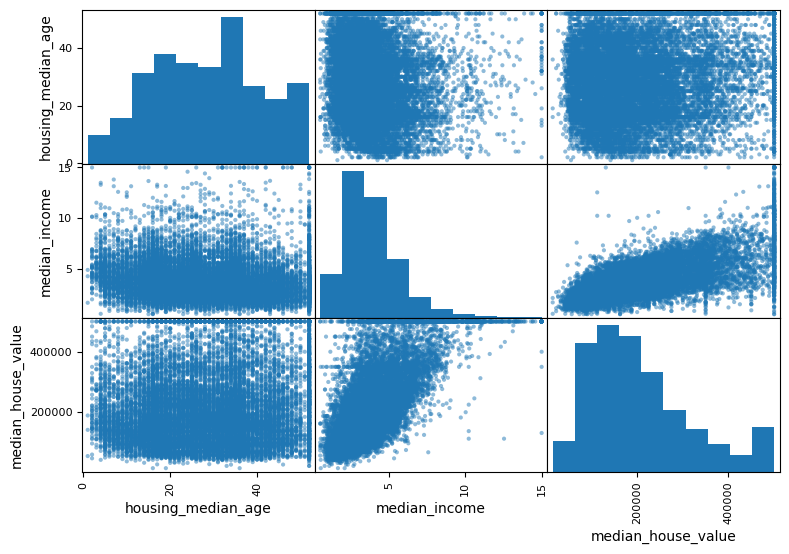

In [144]:
from pandas.plotting import scatter_matrix

attributes=["housing_median_age","median_income","median_house_value"]

scatter_matrix(df[attributes], figsize=(9,6))

## Further Preprocessing

In [145]:
housing= strat_train_set.drop("median_house_value", axis=1) # housing will contain all columns except our label column
housing_label = strat_train_set["median_house_value"].copy() # it will contain our label column

#### Imputing missing values

In [146]:
from sklearn.impute import SimpleImputer # used to fill in missing values (NaNs) in data
imputer = SimpleImputer(strategy="median") # creates an imputer object
 
housing_num = housing.select_dtypes(include=[np.number]) # it will give only those columns that are numeric bcz we can’t compute medians on text/categorical data
imputer.fit(housing_num) # Learn medians from numeric columns (ignoring missing values)

print(imputer.statistics_)

x = imputer.transform(housing_num) # Fill missing values with learned medians
x # x is a numpy array. It contains all numeric columns with imputed values

# This will impute all numeric columns. For non-numeric columns, u can use strategy="most_frequent"

[-118.51      34.26      29.      2119.       433.      1164.
  408.         3.54155]


array([[-1.2146e+02,  3.8520e+01,  2.9000e+01, ...,  2.2370e+03,
         7.0600e+02,  2.1736e+00],
       [-1.1723e+02,  3.3090e+01,  7.0000e+00, ...,  2.0150e+03,
         7.6800e+02,  6.3373e+00],
       [-1.1904e+02,  3.5370e+01,  4.4000e+01, ...,  6.6700e+02,
         3.0000e+02,  2.8750e+00],
       ...,
       [-1.2272e+02,  3.8440e+01,  4.8000e+01, ...,  4.5800e+02,
         1.7200e+02,  3.1797e+00],
       [-1.2270e+02,  3.8310e+01,  1.4000e+01, ...,  1.2080e+03,
         5.0100e+02,  4.1964e+00],
       [-1.2214e+02,  3.9970e+01,  2.7000e+01, ...,  6.2500e+02,
         1.9700e+02,  3.1319e+00]])

In [147]:
# converting back into DataFrame
housing = pd.DataFrame(x, columns=housing_num.columns, index=housing_num.index) 

In [148]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964
...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964


In [149]:
housing['OCEAN_PROXIMITY']=strat_train_set['ocean_proximity'] # adding back that string column

In [150]:
set(housing['OCEAN_PROXIMITY']) # to see all unique values in a column

{'<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'}

### Converting it into a numeric column

 One way is that, we assign a number to each string value in that column , like 0,1,2,3,4
 but in this case, there is a problem with this approach. Our model can learn patterns from this, which do not make any sense in this case.
 But we can follow this approcah when column contains values like: rating 1, rating 2, ... etc.
 This method is called Ordinal Encoding


#### Ordinal Encoding (Not good to use here)

In [151]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()

housing_cat= ordinal_encoder.fit_transform(housing[['OCEAN_PROXIMITY']]) # OrdinalEncoder should only be applied to categorical columns.

housing_cat

array([[1.],
       [4.],
       [1.],
       ...,
       [0.],
       [0.],
       [1.]])

In [152]:
housing_cat = pd.DataFrame(housing_cat , columns=['OCEAN_PROXIMITY'], index=housing.index)
housing_cat

,OCEAN_PROXIMITY
12655,1.0
15502,4.0
2908,1.0
14053,4.0
20496,0.0
...,...
15174,0.0
12661,1.0
19263,0.0
19140,0.0


In [153]:
# Now , Replace original column
# housing['OCEAN_PROXIMITY'] = housing_cat

#### One Hot Encoding (Good to use here)

 Make n new columns (where n is the number of unique values in that string column).
 Each column will corrspond to one value from that string column.
 If that value belongs to that new column, the new column will contain 1, otherwise 0

In [154]:
from sklearn.preprocessing import OneHotEncoder

hot_encoder = OneHotEncoder()

housing_cat_sparse= hot_encoder.fit_transform(housing[['OCEAN_PROXIMITY']]) # fit and tranform in one line

housing_cat_sparse # It returns a sparse matrix (efficient storage for mostly zeros)
# if u dont want sparse matrix, use : hot_encoder = OneHotEncoder(sparse=False)

<16512x5 sparse matrix of type '<class 'numpy.float64'>'
	with 16512 stored elements in Compressed Sparse Row format>

In [155]:
housing_cat_sparse.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

In [156]:
hot_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [157]:
housing_cat = pd.DataFrame(housing_cat_sparse.toarray(), columns=hot_encoder.get_feature_names_out(['OCEAN_PROXIMITY']), index=housing.index)
housing_cat

,OCEAN_PROXIMITY_<1H OCEAN,OCEAN_PROXIMITY_INLAND,OCEAN_PROXIMITY_ISLAND,OCEAN_PROXIMITY_NEAR BAY,OCEAN_PROXIMITY_NEAR OCEAN
12655,0.0,1.0,0.0,0.0,0.0
15502,0.0,0.0,0.0,0.0,1.0
2908,0.0,1.0,0.0,0.0,0.0
14053,0.0,0.0,0.0,0.0,1.0
20496,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...
15174,1.0,0.0,0.0,0.0,0.0
12661,0.0,1.0,0.0,0.0,0.0
19263,1.0,0.0,0.0,0.0,0.0
19140,1.0,0.0,0.0,0.0,0.0


In [158]:
housing_cat.columns = [col.replace('OCEAN_PROXIMITY_', '') for col in housing_cat.columns]
housing_cat

,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
12655,0.0,1.0,0.0,0.0,0.0
15502,0.0,0.0,0.0,0.0,1.0
2908,0.0,1.0,0.0,0.0,0.0
14053,0.0,0.0,0.0,0.0,1.0
20496,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...
15174,1.0,0.0,0.0,0.0,0.0
12661,0.0,1.0,0.0,0.0,0.0
19263,1.0,0.0,0.0,0.0,0.0
19140,1.0,0.0,0.0,0.0,0.0


In [159]:
housing = housing.drop('OCEAN_PROXIMITY', axis=1)
housing =pd.concat([housing, housing_cat], axis=1)
housing # Now it has numeric cols only

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,0.0,1.0,0.0,0.0,0.0
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,0.0,0.0,0.0,0.0,1.0
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,0.0,1.0,0.0,0.0,0.0
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,0.0,0.0,0.0,0.0,1.0
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,1.0,0.0,0.0,0.0,0.0
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,0.0,1.0,0.0,0.0,0.0
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,1.0,0.0,0.0,0.0,0.0
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,1.0,0.0,0.0,0.0,0.0


### Feature Scaling

#### Standarization approch

In [160]:
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()

housing_scaled = scalar.fit_transform(housing)

housing_scaled # np array

array([[-0.94135046,  1.34743822,  0.02756357, ..., -0.0110063 ,
        -0.3548889 , -0.38421741],
       [ 1.17178212, -1.19243966, -1.72201763, ..., -0.0110063 ,
        -0.3548889 ,  2.60269309],
       [ 0.26758118, -0.1259716 ,  1.22045984, ..., -0.0110063 ,
        -0.3548889 , -0.38421741],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ..., -0.0110063 ,
        -0.3548889 , -0.38421741],
       [-1.56080303,  1.2492109 , -1.1653327 , ..., -0.0110063 ,
        -0.3548889 , -0.38421741],
       [-1.28105026,  2.02567448, -0.13148926, ..., -0.0110063 ,
        -0.3548889 , -0.38421741]])

In [161]:
housing = pd.DataFrame(housing_scaled, columns= housing.columns, index= housing.index)
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
12655,-0.941350,1.347438,0.027564,0.584777,0.640371,0.732602,0.556286,-0.893647,-0.887683,1.46218,-0.011006,-0.354889,-0.384217
15502,1.171782,-1.192440,-1.722018,1.261467,0.781561,0.533612,0.721318,1.292168,-0.887683,-0.68391,-0.011006,-0.354889,2.602693
2908,0.267581,-0.125972,1.220460,-0.469773,-0.545138,-0.674675,-0.524407,-0.525434,-0.887683,1.46218,-0.011006,-0.354889,-0.384217
14053,1.221738,-1.351474,-0.370069,-0.348652,-0.036367,-0.467617,-0.037297,-0.865929,-0.887683,-0.68391,-0.011006,-0.354889,2.602693
20496,0.437431,-0.635818,-0.131489,0.427179,0.272790,0.374060,0.220898,0.325752,1.126529,-0.68391,-0.011006,-0.354889,-0.384217
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15174,1.251711,-1.220505,-1.165333,1.890456,1.696862,0.543471,1.341519,0.637374,1.126529,-0.68391,-0.011006,-0.354889,-0.384217
12661,-0.921368,1.342761,-1.085806,2.468471,2.161816,3.002174,2.451492,-0.557509,-0.887683,1.46218,-0.011006,-0.354889,-0.384217
19263,-1.570794,1.310018,1.538566,-0.895802,-0.895679,-0.862013,-0.865118,-0.365475,1.126529,-0.68391,-0.011006,-0.354889,-0.384217
19140,-1.560803,1.249211,-1.165333,0.249005,0.112126,-0.189747,0.010616,0.168261,1.126529,-0.68391,-0.011006,-0.354889,-0.384217


#### Normalization approach

In [ ]:
# from sklearn.preprocessing import MinMaxScaler

# min_max_scaler = MinMaxScaler(feature_range=(-1, 1))

# housing_num_min_max_scaled = min_max_scaler.fit_transform(housing)